In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from setup import *
from plts_funcs import *

## Accretion-ejection instability

$(\omega - m\Omega_\theta)^2 = \Omega_r^2 + \frac{2B_0 |k|}{\Sigma r} + \frac{k^2 c_s^2}{r}$

- $B_0$ campo imperturbato, prpendicolare al disco. legato al materiale del disco - assumiamo legge di potenza con esponenti 0.5, 1, 1.5
- $\Sigma$ densità superficiale, stessa legge radiale di B perché campo legato a questa direttamente.
- assumo disco sottile, con aspect ratio $H/r = 0.05$
- $c_s$ velocità del suono - in disco sottile è dato approssimativamente dalla formula sotto
- k = numero d'onda. loi prendiamo come parametro liberto ma poi controlliamo che stia in range ragionevole ($k \approx 1/H$ con H scala verticale tipica del disco)
- m generalmente il modo eccitato ha un solo braccio, perciò poniamo m=1 per ridurre il numro di parametri


> $B_0 = B_{00} (r/r_{in})^{-\alpha}$

> $\Sigma = \Sigma_0 (r/r_{in})^{-\alpha}$

> $c_s \approx (H/r) v_\varphi = (H/r) r \Omega_\varphi$

> $0.1/r < |k| < 10/r$

dato che l'equazione è una quadratica in |K| risolviamo analiticamente per omega=target. troviamo quindi 

$k(B_{00}, r, \Sigma_0, a)$

con $m = 1, h/r = 0.05, \alpha = 0.5$, M_BH$ fissati

In [27]:
# parametri fissati
mm = 1
alp = 0.5
hor = 0.05

### Implementazione

In [3]:
# ========================================================================
# PROFILI RADIALI
# ========================================================================

def B0_profile(r, a, B00, alpha_exp):
    """
    Campo magnetico: B₀(r) = B₀₀ × (r/r_in)^(-α)
    
    Parameters:
    -----------
    r : array_like
        Radius in gravitational radii
    a : array_like
        Dimensionless spin
    B00 : float
        Normalization at r_in
    alpha_exp : float
        Power-law exponent
    
    Returns:
    --------
    B0 : array_like
        Magnetic field (arbitrary units)
    """
    r = np.asarray(r)
    a = np.asarray(a)
    
    r_in = r_isco(a)
    return B00 * (r / r_in)**(-alpha_exp)


def Sigma_profile(r, a, Sigma0, alpha_exp):
    """
    Surface density: Σ(r) = Σ₀ × (r/r_in)^(-α)
    
    Returns:
    --------
    Sigma : array_like
        Surface density (arbitrary units)
    """
    r = np.asarray(r)
    a = np.asarray(a)
    
    r_in = r_isco(a)
    return Sigma0 * (r / r_in)**(-alpha_exp)


def sound_speed_thin(r, a, hr=0.05, M=M_BH):
    """
    Sound speed in thin disk: c_s ≈ (H/r) × v_φ = (H/r) × r × Ω_φ
    
    Parameters:
    -----------
    hr : float
        Aspect ratio H/r (default: 0.05)
    
    Returns:
    --------
    c_s : array_like
        Sound speed in cm/s
    """
    r = np.asarray(r)
    a = np.asarray(a)
    M = np.asarray(M)
    
    # v_φ = r × Ω_φ = r × (2π ν_φ)
    # Ma ν_φ è già in Hz, quindi v_φ in cm/s è:
    Rg = Rg_SUN * M  # cm
    v_phi = 2 * np.pi * nu_phi(r, a, M) * r * Rg  # cm/s
    
    return hr * v_phi

In [38]:
# ========================================================================
# SOLVER ANALITICO PER k
# ========================================================================

def solve_k_rossby(r, a, B00, Sigma0, alpha_exp=alp, m=mm, hr=hor, M=M_BH):
    """
    Solve for |k| from Rossby wave dispersion relation:
    
    (ω̃ + m·Ω_φ)² = κ² + (2B₀²/Σ)|k| + k²c_s²
    
    This is a quadratic in |k|:
    c_s² × |k|² + (2B₀²/Σ) × |k| + (κ² - ω²) = 0
    
    where ω = ω̃ + m·Ω_φ
    
    Parameters:
    -----------
    r, a, B00, Sigma0, alpha_exp : array_like
        Physical parameters (can be meshgrid arrays)
    m : int
        Azimuthal mode number (default: 1)
    hr : float
        Aspect ratio H/r (default: 0.05)
    
    Returns:
    --------
    k_solutions : dict
        'k_plus': larger solution
        'k_minus': smaller solution
        'valid': boolean mask where solutions are real and positive
    """
    r = np.asarray(r)
    a = np.asarray(a)
    B00 = np.asarray(B00)
    Sigma0 = np.asarray(Sigma0)
    alpha_exp = np.asarray(alpha_exp)
    
    # Compute profiles
    B0 = B0_profile(r, a, B00, alpha_exp)
    Sigma = Sigma_profile(r, a, Sigma0, alpha_exp)
    c_s = sound_speed_thin(r, a, hr, M)
    kappa_sq = (2 * np.pi * nu_r(r, a, M))**2  # rad²/s²
    
    # Target frequency in frame: ω = ω̃ + m·Ω_φ
    omega = 2 * np.pi * NU0  # rad/s (observed frequency)
    Omega_phi = 2 * np.pi * nu_phi(r, a, M)  # rad/s
    omega_tilde = omega - m * Omega_phi
    omega_sq = omega_tilde**2
    
    Rg = Rg_SUN * M  # cm
    r_cm = r * Rg

    # Quadratic coefficients: A|k|² + B|k| + C = 0
    A = c_s**2 / r_cm**2
    B = 2 * B0**2 / ( Sigma * r_cm)
    C = kappa_sq - omega_sq
    
    # Discriminant
    Delta = B**2 - 4*A*C
    
    # Solutions
    k_plus = np.zeros_like(r)
    k_minus = np.zeros_like(r)
    valid = np.zeros_like(r, dtype=bool)
    
    # Only compute where discriminant is non-negative
    mask = Delta >= 0
    
    if np.any(mask):
        sqrt_Delta = np.sqrt(Delta[mask])
        k_plus[mask] = (-B[mask] + sqrt_Delta) / (2*A[mask])
        k_minus[mask] = (-B[mask] - sqrt_Delta) / (2*A[mask])
        
        # Keep only positive solutions
        valid[mask] = (k_plus[mask] > 0) | (k_minus[mask] > 0)
    
    return {
        'k_plus': k_plus,
        'k_minus': k_minus,
        'valid': valid,
        'Delta': Delta
    }


def check_k_physical(k, r, k_min_factor=0.1, k_max_factor=10):
    """
    Check if k is in physical range: k_min/r < |k| < k_max/r
    
    For thin disk with H ~ 0.05r, we expect k ~ 1/H ~ 20/r
    We allow a range [0.1/r, 10/r] to be conservative
    
    Returns:
    --------
    mask : boolean array
        True where k is physical
    """
    k = np.asarray(k)
    r = np.asarray(r)
    
    k_min = k_min_factor / r
    k_max = k_max_factor / r
    
    return (k >= k_min) & (k <= k_max)

In [30]:
# ========================================================================
# FUNZIONE DI MATCHING
# ========================================================================

def find_rossby_matches(param_dict, use_k_plus=True, check_physical=True, m=mm, hr=hor, alpha_exp=alp):
    """
    Find parameter combinations that produce Rossby waves at target frequency.
    
    Parameters:
    -----------
    param_dict : dict
        Parameter grid definition for create_param_grid()
        Must include: 'r', 'a', 'B00', 'Sigma0'
    m : int
        Azimuthal mode number
    hr : float
        Aspect ratio H/r
    alpha_exp : float
        Power-law exponent for B0 and Sigma profiles
    use_k_plus : bool
        If True, use k_plus solution; if False, use k_minus
    check_physical : bool
        If True, filter results where k is not physical
    
    Returns:
    --------
    df : DataFrame
        Matched solutions with columns for all parameters plus 'k'
    """
    # Create parameter grid
    param_vectors, mesh_arrays = create_param_grid(param_dict, mesh=True)
    labels = list(param_dict.keys())
    
    # Extract meshgrid arrays
    param_mesh = {lab: arr for lab, arr in zip(labels, mesh_arrays)}
    
    r = param_mesh['r']
    a = param_mesh['a']
    B00 = param_mesh['B00']
    Sigma0 = param_mesh['Sigma0']
    
    # Solve for k
    k_sols = solve_k_rossby(r, a, B00, Sigma0, alpha_exp, m=m, hr=hr)
    
    # Choose which solution to use
    k = k_sols['k_plus'] if use_k_plus else k_sols['k_minus']
    
    # Build mask
    mask = k_sols['valid']
    
    # Apply ISCO constraint
    a_vec = param_vectors['a']
    isco = r_isco(a_vec)
    r_isco_nd = isco.reshape(-1, *[1]*(r.ndim - 1))
    mask &= (r >= r_isco_nd)
    
    # Apply physical k constraint
    if check_physical:
        mask &= check_k_physical(k, r)
    
    # Collect results
    rows = []
    idxs = np.argwhere(mask)
    
    for idx in idxs:
        idx_tuple = tuple(idx)
        row = {lab: arr[idx_tuple] for lab, arr in param_mesh.items()}
        row['k'] = k[idx_tuple]
        row['k_over_r'] = k[idx_tuple] * r[idx_tuple]
        row['alpha'] = alpha_exp
        row['m'] = m
        row['hr'] = hr
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

### Test del codice

In [41]:
# Definizione griglia parametri
params = {
    'a': [-0.9, 0.9, 21],           # spin
    'r': [1, 100, 100],              # raggio in r_g
    'B00': [1e-3, 1e3, 30],         # normalizzazione campo magnetico (log scale)
    'Sigma0': [1e-3, 1e3, 30],      # normalizzazione densità superficiale (log scale)
}

# Trova matches per alpha = 0.5
print("Cercando soluzioni per α = 0.5...")
df_05 = find_rossby_matches(params, True, False)
print(f"Trovate {len(df_05)} soluzioni")
print("\nPrime 5 righe:")
print(df_05.head())

Cercando soluzioni per α = 0.5...


/home/masterpops/IUSS_tesi/setup.py:193: RuntimeWarning: invalid value encountered in sqrt
  factor = np.sqrt(1 - (6)/r + (8*a)/r**1.5 - (3*a**2)/r**2)


Trovate 522900 soluzioni

Prime 5 righe:
     a         r    B00      Sigma0          k    k_over_r  alpha  m    hr
0 -0.9  8.902151  0.001    0.001000  18.696396  166.438135    0.5  1  0.05
1 -0.9  8.902151  0.001   34.483724  18.696396  166.438135    0.5  1  0.05
2 -0.9  8.902151  0.001   68.966448  18.696396  166.438135    0.5  1  0.05
3 -0.9  8.902151  0.001  103.449172  18.696396  166.438135    0.5  1  0.05
4 -0.9  8.902151  0.001  137.931897  18.696396  166.438135    0.5  1  0.05


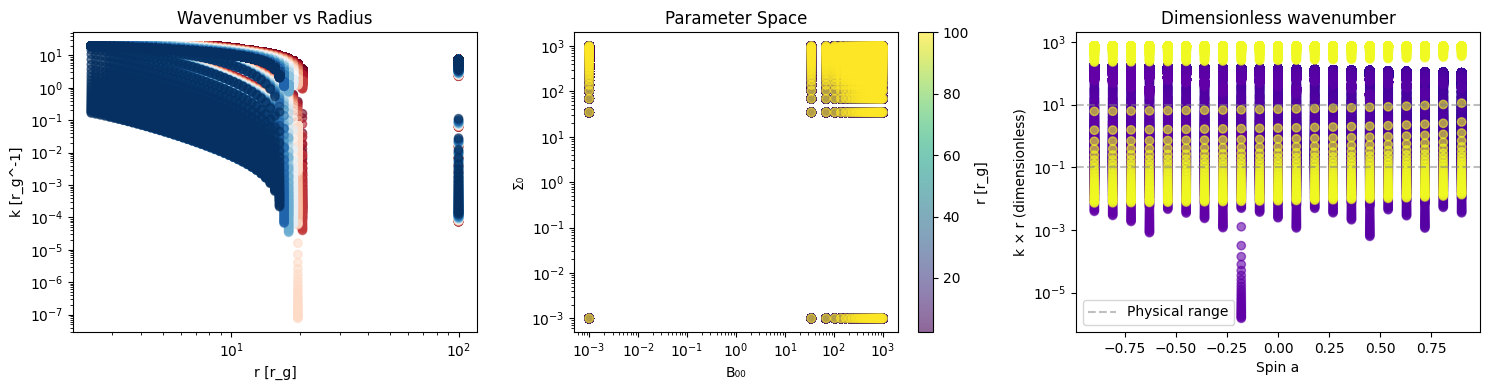

In [42]:
# Visualizzazione rapida
if len(df_05) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # k vs r
    axes[0].scatter(df_05['r'], df_05['k'], c=df_05['a'], alpha=0.6, cmap='RdBu')
    axes[0].set_xlabel('r [r_g]')
    axes[0].set_ylabel('k [r_g^-1]')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_title('Wavenumber vs Radius')
    
    # B00 vs Sigma0
    sc = axes[1].scatter(df_05['B00'], df_05['Sigma0'], c=df_05['r'], 
                         alpha=0.6, cmap='viridis')
    axes[1].set_xlabel('B₀₀')
    axes[1].set_ylabel('Σ₀')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title('Parameter Space')
    plt.colorbar(sc, ax=axes[1], label='r [r_g]')
    
    # k×r (dimensionless)
    axes[2].scatter(df_05['a'], df_05['k_over_r'], c=df_05['r'], 
                    alpha=0.6, cmap='plasma')
    axes[2].set_xlabel('Spin a')
    axes[2].set_ylabel('k × r (dimensionless)')
    axes[2].set_yscale('log')
    axes[2].set_title('Dimensionless wavenumber')
    axes[2].axhline(0.1, ls='--', c='gray', alpha=0.5, label='Physical range')
    axes[2].axhline(10, ls='--', c='gray', alpha=0.5)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna soluzione trovata. Prova ad ampliare i range dei parametri.")